# Donation-Intent Classifier Training — v6: Hierarchical Dialogue Encoder

Fork of `capstone-v5-augfix.ipynb` — same fixed EDA augmentation
(marker-safe tokenizer, deterministic seeding, Persuadee-turn bias; see
[architecture-v5.md](architecture-v5.md)), same data pipeline, same loss
(class-balanced focal + supervised contrastive), same 3-encoder benchmark.
**What changed is the model itself**: this implements README idea #2,
the Hierarchical Dialogue Encoder.

## Why this idea specifically

v3/v4/v5 all encode each dialogue as one flat sequence, tokenized and
truncated to `max_length=256`. Checked against the real dataset
(1017 rows, `dataset-persuassion/Manual_Label.csv`):

```
words/dialogue:  mean=366.5  median=344  p90=548  p95=619  max=1261
```

A 256-token budget covers roughly 180-220 English words for these
tokenizers — **below the median dialogue length**. So the flat encoder
was silently truncating the back half of a *typical* dialogue, not just
outlier long ones, and per `guideline.md`'s own rule of thumb #2 ("use
the persuadee's last clear position, if it changes during the
conversation") the decisive language is exactly the part most likely to
fall past the cutoff on a long dialogue. This is a plausible structural
cause of weak `modifier` performance independent of anything the loss or
pooling changes in v4/v5 could fix.

## Architecture (per README idea #2 / HiTrans, Le et al., 2021)

```
u1  u2  u3  ...  uN                 (dialogue split into turns by [Persuader]/[Persuadee])
        |
 Utterance Encoder (shared weights: RoBERTa-base | DeBERTa-v3-base | TOD-BERT)
        |
CLS1 CLS2 CLS3 ... CLSN             (+ speaker-role embedding, + turn-position embedding)
        |
 Dialogue Transformer (4 layers, configurable)
        |
 Attention pooling over turns
        |
  binary_head + modifier_head (cascaded, unchanged from v4/v5)
```

Each dialogue is split into its individual turns using the same
`[Persuader]`/`[Persuadee]` markers as before — located by regex
*position*, not `text.split(" ")`, so this is marker-safe the same way
v5's augmentation fix is (glued-to-`\n` markers included). Checked
against the real corpus: dialogues have **at most 30 turns** (`p95=23`,
`max=30`), so `max_utterances=32` gives full headroom with no truncation
in practice — a real change from the flat model, which was truncating
most dialogues by content.

Each turn is encoded independently (batched as one flattened
`[B*U, L]` forward pass through the shared transformer, not a Python
loop), then a small Transformer runs over the sequence of turn vectors —
with speaker-role and turn-position embeddings added first — to model
discourse structure across the whole dialogue before pooling down to a
single vector for the two classification heads. The cascaded modifier
head, class-balanced focal loss, supervised contrastive auxiliary loss,
and binary-macro-F1 checkpoint selection are all unchanged from v4/v5.

## Compute cost — read before running

This is a heavier architecture than v3/v4/v5, and the README classifies
it as a "high effort" option for a reason. Each training step now runs
the utterance encoder over `batch_size × ~20` turns instead of
`batch_size` whole dialogues (though each turn is much shorter than the
old 256-token budget, so per-sequence attention cost drops a lot — it's
not a simple multiplier in either direction). To keep memory in check,
per-encoder batch sizes are reduced from v5's (see `CONFIG["encoders"]`
below) and `eval_batch_size` is lower too. **Expect this to run
noticeably longer than v3/v4/v5's ~15-20 min** — plan for something in
the 1-3+ hour range for all three encoders on a free Kaggle T4, depending
on how early each encoder's early-stopping fires. To do a faster first
pass, trim `CONFIG["encoders"]` down to one entry, or lower
`CONFIG["num_epochs"]` / `CONFIG["early_stopping_patience"]`.

Outputs are suffixed `_v6` / `checkpoints_v6/`, so this can run in the
same working directory as v3/v4/v5 without clobbering their artifacts.

## 0b. Install / upgrade dependencies

In [1]:
# =============================================================
# 0b. INSTALL / UPGRADE DEPENDENCIES (online mode)
# =============================================================
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "transformers>=4.44.0,<4.47.0", "sentencepiece", "tqdm",
    "seaborn", "scikit-learn",
], check=True)
# --no-deps: keep the GPU-matched torch already on the Kaggle image
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "--no-deps", "accelerate>=0.34.0",
], check=True)
print("All required Python packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 63.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 5.3 MB/s eta 0:00:00
All required Python packages installed successfully.


## 1. Imports & global config

In [2]:
# =============================================================
# 1. IMPORTS & GLOBAL CONFIG
# =============================================================
import os, re, json, glob, gc, time, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"torch version: {torch.__version__} (built for CUDA {torch.version.cuda})")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- CONFIG: the only block you should need to touch -----------------
CONFIG = {
    # Same fuzzy recursive search-root convention as v3, so this works
    # unmodified whether the labeled CSV is added as a Kaggle Dataset
    # input or dropped anywhere under these roots.
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data", "."],

    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",
    # v6 writes its own output filenames (suffixed "_v6") and its own
    # checkpoint subdirectory, so this can run in the same out_dir as
    # v3/v4/v5 without clobbering their artifacts.
    "run_tag": "v6",

    "column_map": {
        "text": "dialogue_text",
        "binary_label": "binary_label",
        "modifier": "modifier",
    },

    "binary_classes": ["no", "yes"],
    "modifier_classes": ["none", "deferred", "conditional"],

    # Batch sizes are lower than v3/v4/v5's: the utterance encoder sees
    # batch_size * (turns/dialogue, ~20 typical, up to 32) flattened
    # sequences per forward pass instead of batch_size whole dialogues,
    # so effective memory pressure is much higher per training step even
    # though each individual sequence is short. DeBERTa-v3 needs the
    # largest cut (it already needed a reduced batch in v3/v4/v5).
    "encoders": [
        {"name": "roberta-base",    "hf_id": "roberta-base",          "batch_size": 8},
        {"name": "deberta-v3-base", "hf_id": "microsoft/deberta-v3-base", "lr": 5e-6, "batch_size": 4, "warmup_ratio": 0.10},
        {"name": "todbert",         "hf_id": "TODBERT/TOD-BERT-JNT-V1", "batch_size": 8},
    ],

    # Per-utterance token budget and max turns/dialogue. The real corpus
    # never exceeds 30 turns/dialogue (p95=23, p99=25) and 98.7% of
    # individual turns are under 64 words, so these give full headroom
    # with truncation essentially never firing (see the v6 intro cell for
    # the measured distribution).
    "max_utterances": 32,
    "max_utt_len": 64,

    # Dialogue-level Transformer (encodes discourse structure across the
    # sequence of turn vectors). README's HiTrans sketch suggests 6
    # layers; defaulting lower here since this dataset is small (~1000
    # augmented training dialogues) and a deep transformer over only
    # ~20 turn-vectors per example risks overfitting/instability faster
    # than it helps -- bump this if you have the compute budget to check.
    "dialogue_num_layers": 4,
    "dialogue_num_heads": 8,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    "batch_size": 8,
    "eval_batch_size": 16,
    "num_epochs": 25,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,

    "binary_loss_weight": 1.0,
    "modifier_loss_weight": 0.7,

    # Data augmentation (EDA, kept from v3, unchanged) -----------------
    "use_augmentation": True,
    "aug_alpha": 0.15,
    "aug_num_conditional": 6,
    "aug_num_deferred": 2,
    "aug_num_no": 1,
    # v5: bias synonym-replacement/insertion toward Persuadee-turn
    # tokens (0.0 = fully uniform like v3/v4, 1.0 = Persuadee tokens
    # always tried first). Labels are defined entirely by what the
    # Persuadee says (guideline.md), so this spends more of the
    # perturbation budget where the signal actually is.
    "aug_persuadee_bias_weight": 0.75,

    # ---- v4: Class-Balanced Focal Loss (replaces v3's inverse-freq
    # weighted CE + label smoothing) --------------------------------
    # "Class-Balanced Loss Based on Effective Number of Samples"
    # (Cui et al., 2019, CVPR). beta close to 1 -> weight ~ inverse
    # frequency for well-populated classes but saturates gracefully for
    # near-zero-sample classes (e.g. conditional) instead of exploding.
    "cb_beta": 0.999,
    # Focal-loss focusing parameter: down-weights already-easy/confident
    # predictions so the loss keeps pushing on hard/minority examples
    # for the whole run, not just at initialisation.
    "focal_gamma": 2.0,

    # ---- v4: Supervised Contrastive auxiliary loss --------------------
    # In-batch, single-stage (no separate pretraining pass -> cheap).
    # Pulls same-class pooled representations together / pushes apart.
    # Modifier weight is higher because that is the head that collapses
    # hardest (85.6% "none").
    "use_contrastive": True,
    "contrastive_temperature": 0.1,
    "contrastive_weight_binary": 0.10,
    "contrastive_weight_modifier": 0.30,

    "early_stopping_patience": 5,
    "checkpoint_dir_name": "checkpoints_v6",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "encoders"}, indent=2))
print("Encoders:", [m["hf_id"] for m in CONFIG["encoders"]])

Using device: cuda
torch version: 2.10.0+cu128 (built for CUDA 12.8)
GPU: Tesla T4
{
  "search_roots": [
    "/kaggle/input",
    "/kaggle/working",
    "/workspace",
    "/data",
    "."
  ],
  "out_dir": "/kaggle/working",
  "run_tag": "v6",
  "column_map": {
    "text": "dialogue_text",
    "binary_label": "binary_label",
    "modifier": "modifier"
  },
  "binary_classes": [
    "no",
    "yes"
  ],
  "modifier_classes": [
    "none",
    "deferred",
    "conditional"
  ],
  "max_utterances": 32,
  "max_utt_len": 64,
  "dialogue_num_layers": 4,
  "dialogue_num_heads": 8,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "batch_size": 8,
  "eval_batch_size": 16,
  "num_epochs": 25,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "binary_loss_weight": 1.0,
  "modifier_loss_weight": 0.7,
  "use_augmentation": true,
  "aug_alpha": 0.15,
  "aug_num_conditional": 6,
  "aug_num_deferred": 2,
  "aug_num_no": 1,
  "aug_persuadee_bias_wei

## 2. Load the labeled dataset

In [3]:
# =============================================================
# 2. DATA DISCOVERY & LOADING  (unchanged from v3)
# =============================================================

def find_files_ci(roots, must_contain_all, suffix):
    must_contain_all = [t.lower() for t in must_contain_all]
    suffix = suffix.lower()
    found = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, filenames in os.walk(root):
            for fn in filenames:
                low = fn.lower()
                if low.endswith(suffix) and all(tok in low for tok in must_contain_all):
                    found.append(os.path.join(dirpath, fn))
    seen, unique = set(), []
    for f in found:
        if f not in seen:
            seen.add(f)
            unique.append(f)
    return unique

csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["label"], suffix=".csv")
if not csv_paths:
    csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["manual"], suffix=".csv")

print(f"Found {len(csv_paths)} candidate CSV(s):")
for p in csv_paths:
    print(" -", p)

assert len(csv_paths) > 0, (
    "No labeled CSV found under " + str(CONFIG["search_roots"]) +
    ". Make sure the labeled dataset has been added as a Kaggle input "
    "(Notebook -> Add Input), or update CONFIG['search_roots']."
)

_dfs = [pd.read_csv(p) for p in csv_paths]
raw_df = pd.concat(_dfs, ignore_index=True) if len(_dfs) > 1 else _dfs[0]

cm = CONFIG["column_map"]
missing_cols = [c for c in cm.values() if c not in raw_df.columns]
assert not missing_cols, (
    f"Expected column(s) {missing_cols} not found in loaded CSV(s). "
    f"Columns present: {list(raw_df.columns)}. "
    "Update CONFIG['column_map'] to match the new dataset's headers."
)

df = raw_df.rename(columns={v: k for k, v in cm.items()})[list(cm.keys())].copy()

orig_id_col = None
for cand in ["conversation_id", "dialogue_id", "id"]:
    if cand in raw_df.columns:
        orig_id_col = cand
        break
if orig_id_col is not None:
    df["_orig_id"] = raw_df[orig_id_col].values
    before = len(df)
    df = df.drop_duplicates(subset="_orig_id").drop(columns="_orig_id").reset_index(drop=True)
    if len(df) != before:
        print(f"Dropped {before - len(df)} duplicate row(s) by `{orig_id_col}`.")

df["text"] = df["text"].fillna("").astype(str)
df["binary_label"] = df["binary_label"].fillna("").astype(str).str.strip().str.lower()

df["modifier"] = df["modifier"].fillna("").astype(str).str.strip().str.lower()
df.loc[df["modifier"].isin(["", "nan", "none provided", "na"]), "modifier"] = "none"

bad_binary = ~df["binary_label"].isin(CONFIG["binary_classes"])
bad_modifier = ~df["modifier"].isin(CONFIG["modifier_classes"])
if bad_binary.any() or bad_modifier.any():
    print(f"WARNING: dropping {int((bad_binary | bad_modifier).sum())} row(s) with "
          f"out-of-vocabulary binary_label/modifier values.")
    print("  bad binary_label values:", sorted(df.loc[bad_binary, "binary_label"].unique()))
    print("  bad modifier values:", sorted(df.loc[bad_modifier, "modifier"].unique()))
    df = df.loc[~(bad_binary | bad_modifier)].reset_index(drop=True)

df["binary_id"] = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})
df["modifier_id"] = df["modifier"].map({c: i for i, c in enumerate(CONFIG["modifier_classes"])})

print(f"\nLoaded {len(df)} labeled rows after cleaning.")
df.head()

Found 1 candidate CSV(s):
 - /kaggle/input/datasets/nawrizturjo/persuasion-1/Manual_Label.csv

Loaded 1017 labeled rows after cleaning.


,text,binary_label,modifier,binary_id,modifier_id
0,"[Persuader] Good morning\n [Persuadee] Good morning \n [Persuader] We are seeking donations for the ""Save the Childr...",yes,none,1,0
1,[Persuader] Could you please donate all of your$2 to Save the Children? Hunger kills millions of children worldwide ...,yes,none,1,0
2,[Persuader] Hello! How are you doing?\n [Persuadee] I am quite good. How about yourself? \n [Persuader] I am doing a...,no,none,0,0
3,"[Persuader] Good evening. How are you doing?\n [Persuadee] I'm doing pretty good, how about yourself?\n [Persuader] ...",yes,none,1,0
4,[Persuader] Hi! How are you today?\n [Persuadee] good :) how are you?\n [Persuader] I'm good. Thanks for asking. Hav...,yes,none,1,0


## 2b. Class distribution & majority-class baseline

binary_label distribution:
binary_label
yes    738
no     279
Name: count, dtype: int64 

modifier distribution:
modifier
none           871
deferred       125
conditional     21
Name: count, dtype: int64 

modifier distribution, restricted to binary_label == 'yes' rows (the population the modifier head is conditioned on):
modifier
none           657
deferred        68
conditional     13
Name: count, dtype: int64


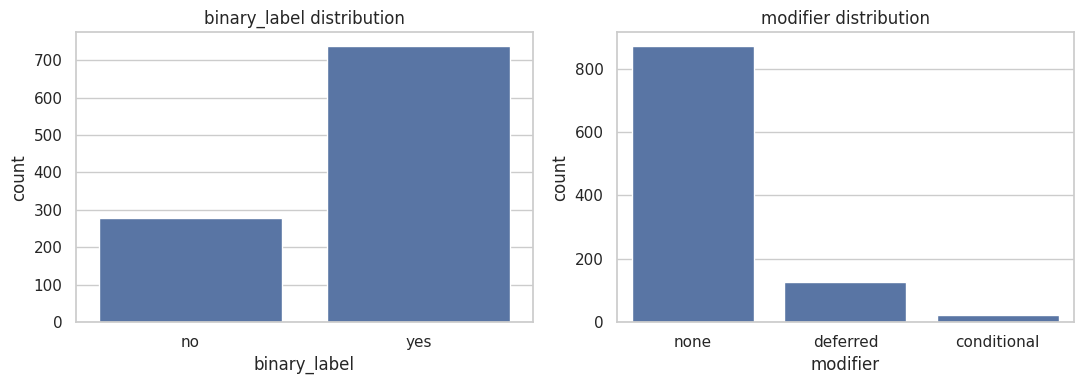


Majority-class baseline (whole dataset, for reference -- the real reported baseline further down uses the TEST split only):
  binary_label: {'majority_class': np.int64(1), 'accuracy': 0.7256637168141593, 'macro_f1': 0.4205128205128205}
  modifier    : {'majority_class': np.int64(0), 'accuracy': 0.856440511307768, 'macro_f1': 0.3075564971751413}


In [4]:
# =============================================================
# 2b. CLASS DISTRIBUTION & MAJORITY-CLASS BASELINE  (unchanged from v3)
# =============================================================
print("binary_label distribution:")
print(df["binary_label"].value_counts(), "\n")
print("modifier distribution:")
print(df["modifier"].value_counts(), "\n")
print("modifier distribution, restricted to binary_label == 'yes' rows "
      "(the population the modifier head is conditioned on):")
print(df.loc[df["binary_label"] == "yes", "modifier"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="binary_label", order=CONFIG["binary_classes"], ax=axes[0])
axes[0].set_title("binary_label distribution")
sns.countplot(data=df, x="modifier", order=CONFIG["modifier_classes"], ax=axes[1])
axes[1].set_title("modifier distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "label_distribution.png"), dpi=150)
plt.show()

def majority_baseline(y_true_ids, n_classes):
    majority_class = Counter(y_true_ids).most_common(1)[0][0]
    y_pred = [majority_class] * len(y_true_ids)
    acc = accuracy_score(y_true_ids, y_pred)
    f1_macro = f1_score(y_true_ids, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0)
    return {"majority_class": majority_class, "accuracy": acc, "macro_f1": f1_macro}

baseline_binary = majority_baseline(df["binary_id"].values, len(CONFIG["binary_classes"]))
baseline_modifier = majority_baseline(df["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("\nMajority-class baseline (whole dataset, for reference -- the real "
      "reported baseline further down uses the TEST split only):")
print("  binary_label:", baseline_binary)
print("  modifier    :", baseline_modifier)

## 3. Stratified 70/15/15 train/val/test split

In [5]:
# =============================================================
# 3. STRATIFIED 70/15/15 SPLIT (by binary_label x modifier combination) -- unchanged from v3
# =============================================================

df["_stratum"] = df["binary_label"] + "_" + df["modifier"]

strat_counts = df["_stratum"].value_counts()
rare = strat_counts[strat_counts < 2].index
df.loc[df["_stratum"].isin(rare), "_stratum"] = "_singleton_bucket"

train_df, temp_df = train_test_split(
    df, test_size=(CONFIG["val_frac"] + CONFIG["test_frac"]),
    stratify=df["_stratum"], random_state=SEED,
)
temp_counts = temp_df["_stratum"].value_counts()
rare2 = temp_counts[temp_counts < 2].index
temp_df = temp_df.copy()
temp_df.loc[temp_df["_stratum"].isin(rare2), "_stratum"] = "_singleton_bucket"

rel_test_size = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_df, test_df = train_test_split(
    temp_df, test_size=rel_test_size,
    stratify=temp_df["_stratum"], random_state=SEED,
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(split)} ({len(split)/len(df):.1%})")

print("\nbinary_label composition per split:")
display(pd.concat({
    "train": train_df["binary_label"].value_counts(normalize=True),
    "val": val_df["binary_label"].value_counts(normalize=True),
    "test": test_df["binary_label"].value_counts(normalize=True),
}, axis=1))

print("\nmodifier composition per split:")
display(pd.concat({
    "train": train_df["modifier"].value_counts(normalize=True),
    "val": val_df["modifier"].value_counts(normalize=True),
    "test": test_df["modifier"].value_counts(normalize=True),
}, axis=1))

for split in (train_df, val_df, test_df):
    split.drop(columns=["_stratum"], inplace=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train: n=711 (69.9%)
val: n=153 (15.0%)
test: n=153 (15.0%)

binary_label composition per split:


,train,val,test
binary_label,,,
yes,0.724332,0.732026,0.72549
no,0.275668,0.267974,0.27451



modifier composition per split:


,train,val,test
modifier,,,
none,0.856540,0.856209,0.856209
deferred,0.122363,0.124183,0.124183
conditional,0.021097,0.019608,0.019608


## 3b. Data Augmentation (EDA) — TRAIN SPLIT ONLY (v5: fixed)

In [6]:
# =============================================================
# 3b. EDA AUGMENTATION (train split only, label-safety-guarded)  -- v5 FIXES:
#   1. marker-safe tokenizer (regex, not text.split(" "))
#   2. hashlib-based deterministic seeding (not Python's randomized hash())
#   3. Persuadee-turn-biased synonym replacement / insertion
# =============================================================
import re
import random as _random
import hashlib

PROTECTED_WORDS = {
    "if", "unless", "provided", "as", "long", "condition", "conditional",
    "after", "once", "later", "when", "then", "next", "eventually",
    "promise", "will", "would", "could", "might", "may", "maybe",
    "paycheck", "payday", "month", "week", "tomorrow", "soon",
    "not", "no", "never", "don't", "dont", "won't", "wont", "can't", "cant",
    "donate", "donation", "give", "money", "charity", "pledge",
}
SPEAKER_MARKERS = {"[persuader]", "[persuadee]"}

_SYNONYMS = {
    "good": ["nice", "great", "fine", "decent"],
    "really": ["truly", "genuinely", "honestly"],
    "think": ["believe", "feel", "figure"],
    "want": ["would like", "wish", "hope"],
    "help": ["assist", "support", "aid"],
    "people": ["folks", "individuals", "persons"],
    "important": ["significant", "vital", "essential"],
    "cause": ["mission", "campaign", "effort"],
    "understand": ["see", "get", "realize"],
    "sure": ["certain", "confident", "positive"],
    "sorry": ["apologies", "regret", "my bad"],
    "okay": ["alright", "fine", "sure"],
    "thanks": ["thank you", "appreciate it", "cheers"],
    "great": ["awesome", "wonderful", "fantastic"],
    "kids": ["children", "youth", "young ones"],
    "families": ["households", "homes"],
    "problem": ["issue", "trouble", "difficulty"],
    "talk": ["chat", "speak", "discuss"],
    "guess": ["suppose", "reckon", "figure"],
    "job": ["work", "career", "position"],
    "busy": ["swamped", "occupied", "tied up"],
}

def _get_synonym(word):
    lw = word.lower()
    if lw in _SYNONYMS:
        return _random.choice(_SYNONYMS[lw])
    return None

# v5 FIX 1: [Persuader]/[Persuadee] matched as their own atomic token
# FIRST, regardless of what they're glued to. v3/v4 used text.split(" "),
# which only isolates a marker when it happens to already be
# space-delimited -- empirically true for only ~42% of markers in this
# corpus; the other ~58% are glued straight onto "\n" or the previous
# word (e.g. "today?\n[Persuadee]"), so the marker-protection check never
# matched them and they were exposed to swap/delete corruption.
_TOKEN_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]|\S+')

def _tokenize_protecting_markers(text):
    return _TOKEN_PATTERN.findall(text)

def _is_locked(tok):
    low = tok.strip(".,!?;:\"'").lower()
    return low in PROTECTED_WORDS or low in SPEAKER_MARKERS or tok.lower() in SPEAKER_MARKERS

def _tag_token_roles(words):
    """Tag each token with its enclosing speaker turn ('persuader' /
    'persuadee' / 'other' before the first marker). Used only to bias
    WHICH words augmentation prefers to touch -- has no effect on the
    actual model's speaker-role embedding, which in v6 is assigned per
    TURN by split_into_utterances() further down (v4/v5's token-level
    compute_batch_role_ids() is not used in this hierarchical model)."""
    roles = []
    current = "other"
    for w in words:
        low = w.lower()
        if low == "[persuader]":
            current = "persuader"
        elif low == "[persuadee]":
            current = "persuadee"
        roles.append(current)
    return roles

def _ranked_candidates(indices, roles, bias_weight):
    """Order candidate indices so Persuadee-turn ones are tried first with
    probability bias_weight -- never excludes Persuader-turn candidates
    outright, since short conditional/deferred dialogues can be almost
    entirely one speaker's words."""
    persuadee = [i for i in indices if roles[i] == "persuadee"]
    other = [i for i in indices if roles[i] != "persuadee"]
    _random.shuffle(persuadee)
    _random.shuffle(other)
    if _random.random() < bias_weight:
        return persuadee + other
    return other + persuadee

def eda_synonym_replacement(words, n, roles=None, bias_weight=0.0):
    new_words = words.copy()
    candidates = [i for i, w in enumerate(new_words) if not _is_locked(w) and _get_synonym(w)]
    if roles is not None and bias_weight > 0:
        candidates = _ranked_candidates(candidates, roles, bias_weight)
    else:
        _random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        syn = _get_synonym(new_words[idx])
        if syn:
            new_words[idx] = syn
            replaced += 1
        if replaced >= n:
            break
    return new_words

def eda_random_deletion(words, p):
    # Role-agnostic on purpose (see v5 intro cell): deletion is structural
    # noise/shortening, not phrasing diversity, and Persuadee turns can be
    # very short already in conditional/deferred rows.
    if len(words) <= 3:
        return words.copy()
    new_words = []
    for w in words:
        if _is_locked(w):
            new_words.append(w)
        elif _random.random() > p:
            new_words.append(w)
    if len(new_words) == 0:
        return [words[_random.randrange(len(words))]]
    return new_words

def eda_random_swap(words, n):
    # Role-agnostic on purpose -- see eda_random_deletion above.
    new_words = words.copy()
    swappable = [i for i, w in enumerate(new_words) if not _is_locked(w)]
    for _ in range(n):
        if len(swappable) < 2:
            break
        i, j = _random.sample(swappable, 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def eda_random_insertion(words, n, roles=None, bias_weight=0.0):
    # Source word to duplicate-as-synonym is chosen from the ORIGINAL
    # (fixed) word/role list, not the growing new_words list -- keeps
    # role-index alignment simple and correct as the list grows.
    new_words = words.copy()
    base_candidates = [i for i, w in enumerate(words) if not _is_locked(w) and _get_synonym(w)]
    for _ in range(n):
        if not base_candidates:
            break
        if roles is not None and bias_weight > 0:
            idx = _ranked_candidates(base_candidates, roles, bias_weight)[0]
        else:
            idx = _random.choice(base_candidates)
        syn = _get_synonym(words[idx])
        insert_pos = _random.randrange(len(new_words) + 1)
        new_words.insert(insert_pos, syn)
    return new_words

def eda_augment_one(text, alpha=0.15, seed=None, bias_weight=0.0):
    if seed is not None:
        _random.seed(seed)
    words = _tokenize_protecting_markers(text)
    roles = _tag_token_roles(words) if bias_weight > 0 else None
    n_ops = max(1, int(alpha * len(words)))

    op = _random.choice(["synonym", "swap", "delete", "insert"])
    if op == "synonym":
        words = eda_synonym_replacement(words, n_ops, roles=roles, bias_weight=bias_weight)
    elif op == "swap":
        words = eda_random_swap(words, n_ops)
    elif op == "delete":
        words = eda_random_deletion(words, p=alpha)
    else:
        words = eda_random_insertion(words, n_ops, roles=roles, bias_weight=bias_weight)

    return " ".join(words)

# v5 FIX 2: hashlib-based deterministic seed, stable across processes/runs.
# Python's built-in hash() on strings is randomized per-process
# (PYTHONHASHSEED) -- v3/v4's seed=hash((text, k)) % (2**31) silently
# produced different augmented text on every kernel restart despite
# CONFIG["SEED"] being fixed. sha256 is stable by construction.
def _stable_seed(*parts):
    h = hashlib.sha256("::".join(str(p) for p in parts).encode("utf-8")).hexdigest()
    return int(h[:8], 16)

def augment_dataframe_for_minority_classes(df, config, seed=42):
    _random.seed(seed)
    rows_to_add = []
    bias_weight = config.get("aug_persuadee_bias_weight", 0.0)

    yes_idx = config["binary_classes"].index("yes")
    no_idx = config["binary_classes"].index("no")
    cond_idx = config["modifier_classes"].index("conditional")
    def_idx = config["modifier_classes"].index("deferred")

    plan = [
        (df["binary_id"] == yes_idx) & (df["modifier_id"] == cond_idx), config["aug_num_conditional"],
        (df["binary_id"] == yes_idx) & (df["modifier_id"] == def_idx),  config["aug_num_deferred"],
        (df["binary_id"] == no_idx),                                   config["aug_num_no"],
    ]
    for mask, n_copies in zip(plan[0::2], plan[1::2]):
        subset = df.loc[mask]
        for _, row in subset.iterrows():
            for k in range(n_copies):
                aug_text = eda_augment_one(row["text"], alpha=config["aug_alpha"],
                                            seed=_stable_seed(row["text"], k),
                                            bias_weight=bias_weight)
                new_row = row.copy()
                new_row["text"] = aug_text
                rows_to_add.append(new_row)

    if not rows_to_add:
        return df.reset_index(drop=True)

    aug_df = pd.DataFrame(rows_to_add)
    out = pd.concat([df, aug_df], ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


if CONFIG.get("use_augmentation", False):
    _before_n = len(train_df)
    _before_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    train_df = augment_dataframe_for_minority_classes(train_df, CONFIG, seed=SEED)

    _after_n = len(train_df)
    _after_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    print(f"Train split size: {_before_n} -> {_after_n} rows after EDA augmentation")
    print("\nmodifier distribution among binary=yes TRAIN rows, before -> after:")
    display(pd.concat({"before": _before_dist, "after": _after_dist}, axis=1).fillna(0).astype(int))
    print("\nbinary_label distribution after augmentation:")
    print(train_df["binary_label"].value_counts())
else:
    print("Augmentation disabled (CONFIG['use_augmentation'] = False).")

Train split size: 711 -> 1055 rows after EDA augmentation

modifier distribution among binary=yes TRAIN rows, before -> after:


,before,after
modifier,,
none,459,459
deferred,47,141
conditional,9,63



binary_label distribution after augmentation:
binary_label
yes    663
no     392
Name: count, dtype: int64


### 3c. Augmentation QA — marker-integrity self-check (new in v5)

Runs the fixed augmentation against every training row and checks that the number of `[Persuader]`/`[Persuadee]` markers is preserved. On v3/v4's tokenizer this failed on 15.9% of variants; expect ~0% here.

In [7]:
# =============================================================
# 3c. AUGMENTATION QA -- marker-integrity self-check (v5)
# =============================================================
_marker_pattern = re.compile(r'\[Persuader\]|\[Persuadee\]')

def _marker_count(t):
    return len(_marker_pattern.findall(t))

_n_checked = 0
_n_mismatch = 0
_mismatch_examples = []
_bias_weight = CONFIG.get("aug_persuadee_bias_weight", 0.0)

for _, _row in train_df.iterrows():
    _orig_markers = _marker_count(_row["text"])
    if _orig_markers == 0:
        continue
    for _k in range(3):
        _aug_text = eda_augment_one(_row["text"], alpha=CONFIG["aug_alpha"],
                                     seed=_stable_seed(_row["text"], f"qa{_k}"),
                                     bias_weight=_bias_weight)
        _aug_markers = _marker_count(_aug_text)
        _n_checked += 1
        if _aug_markers != _orig_markers:
            _n_mismatch += 1
            if len(_mismatch_examples) < 3:
                _mismatch_examples.append((_orig_markers, _aug_markers, _row["text"][:100], _aug_text[:100]))

print(f"Checked {_n_checked} augmented variants across {len(train_df)} (post-augmentation) train rows.")
print(f"Marker-count mismatches: {_n_mismatch} ({_n_mismatch / max(_n_checked, 1):.2%})")
if _mismatch_examples:
    print("\nExample mismatches:")
    for _o, _a, _ot, _at in _mismatch_examples:
        print(f"  orig_markers={_o} aug_markers={_a}\n    ORIG: {_ot!r}\n    AUG : {_at!r}")
else:
    print("No marker corruption detected.")


Checked 3165 augmented variants across 1055 (post-augmentation) train rows.
Marker-count mismatches: 0 (0.00%)
No marker corruption detected.


## 4. Dataset, utterance splitting & hierarchical batching (v6)

In [8]:
# =============================================================
# 4. TORCH DATASET + UTTERANCE SPLITTING + HIERARCHICAL COLLATE  (v6)
# =============================================================
import re

_SPEAKER_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]')
ROLE_PERSUADER = 0
ROLE_PERSUADEE = 1
ROLE_PAD       = 2   # padding turn-slot (dialogue shorter than batch max)


class DonationIntentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.binary_ids = dataframe["binary_id"].tolist()
        self.modifier_ids = dataframe["modifier_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "binary_id": self.binary_ids[idx],
            "modifier_id": self.modifier_ids[idx],
        }


def split_into_utterances(text, max_utterances=32):
    """
    Split a dialogue into (speaker_role, utterance_text) turns using
    [Persuader]/[Persuadee] markers located by regex POSITION -- not
    text.split(" ") -- so this is robust regardless of whether a marker
    is glued to surrounding whitespace/punctuation (57.5% of markers in
    this corpus are glued to a preceding "\n" with no space; see v5's
    augmentation fix for the full measurement).

    If a dialogue has more than max_utterances turns, the EARLIEST turns
    are dropped and the most recent max_utterances are kept -- donation
    intent is usually resolved near the end of a conversation
    (guideline.md: "use the persuadee's last clear position"). In
    practice this corpus never exceeds 30 turns, so with the default
    max_utterances=32 this branch does not fire.
    """
    matches = list(_SPEAKER_PATTERN.finditer(text))
    utterances = []
    for i, m in enumerate(matches):
        role = ROLE_PERSUADER if m.group() == "[Persuader]" else ROLE_PERSUADEE
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt_text = text[start:end].strip()
        if utt_text:
            utterances.append((role, utt_text))
    if len(utterances) > max_utterances:
        utterances = utterances[-max_utterances:]
    return utterances


def make_hier_collate_fn(tokenizer, max_utt_len, max_utterances):
    """
    Builds a batch of shape [B, U, L] (U = max turns present in this
    batch, L = max tokens across all turns in this batch, both dynamic --
    not padded to the global max_utterances/max_utt_len caps) plus:
      - utt_mask [B, U]  : 1 = real turn, 0 = padding turn-slot
      - role_ids [B, U]  : ROLE_PERSUADER / ROLE_PERSUADEE / ROLE_PAD

    Padding turn-slots (dialogues shorter than this batch's U) get a
    single valid dummy token (the tokenizer's CLS/BOS id, attention_mask=1
    at position 0 only) rather than an all-zero attention mask -- avoids
    relying on every encoder implementation handling a fully-masked
    sequence identically; utt_mask excludes these slots from both the
    dialogue transformer (src_key_padding_mask) and the final attention
    pooling, so their (unused) encoded vector never reaches the heads.
    """
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    cls_id = tokenizer.cls_token_id
    if cls_id is None:
        cls_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else pad_id

    def collate_fn(batch):
        all_utts = []
        for b in batch:
            utts = split_into_utterances(b["text"], max_utterances=max_utterances)
            if not utts:
                utts = [(ROLE_PERSUADEE, "")]   # degenerate fallback, should not occur on this corpus
            all_utts.append(utts)

        B = len(all_utts)
        U = max(len(u) for u in all_utts)

        flat_texts, flat_roles, owner = [], [], []
        for di, utts in enumerate(all_utts):
            for ui, (role, text) in enumerate(utts):
                flat_texts.append(text if text.strip() else " ")
                flat_roles.append(role)
                owner.append((di, ui))

        enc = tokenizer(flat_texts, padding=True, truncation=True,
                         max_length=max_utt_len, return_tensors="pt")
        L = enc["input_ids"].shape[1]

        input_ids = torch.full((B, U, L), pad_id, dtype=torch.long)
        attn_mask = torch.zeros(B, U, L, dtype=torch.long)
        utt_mask  = torch.zeros(B, U, dtype=torch.long)
        role_ids  = torch.full((B, U), ROLE_PAD, dtype=torch.long)

        input_ids[:, :, 0] = cls_id   # safe dummy token everywhere, overwritten below for real turns

        for flat_idx, (di, ui) in enumerate(owner):
            input_ids[di, ui] = enc["input_ids"][flat_idx]
            attn_mask[di, ui] = enc["attention_mask"][flat_idx]
            utt_mask[di, ui] = 1
            role_ids[di, ui] = flat_roles[flat_idx]

        pad_slot = (utt_mask == 0)
        attn_mask[:, :, 0] = attn_mask[:, :, 0].masked_fill(pad_slot, 1)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "utt_mask": utt_mask,
            "role_ids": role_ids,
            "binary_labels":   torch.tensor([b["binary_id"]   for b in batch], dtype=torch.long),
            "modifier_labels": torch.tensor([b["modifier_id"] for b in batch], dtype=torch.long),
        }
    return collate_fn

## 5. Model architecture — hierarchical dialogue encoder (v6, README idea #2)

```
input_ids, attention_mask   [B, U, L]   (U turns, L tokens/turn, both dynamic per batch)
        |
   flatten to [B*U, L], ONE batched forward pass through the shared
   utterance encoder (RoBERTa-base | DeBERTa-v3-base | TOD-BERT)
        |
   masked mean-pool each turn's last_hidden_state -> [B*U, H] -> reshape [B, U, H]
        |
   +--(+)-- Speaker-Role Embedding   nn.Embedding(3, H)   {Persuader, Persuadee, pad}
   +--(+)-- Turn-Position Embedding  nn.Embedding(max_utterances, H)
        |
   Dialogue Transformer (nn.TransformerEncoder, 4 layers, batch_first=True)
   src_key_padding_mask = ~utt_mask   (padding turn-slots excluded from attention)
        |
   Attention pooling over turns (same learned-score mechanism as v4/v5,
   applied over the turn dimension instead of the token dimension)
        |
   shared_repr [B, H]
        |
   +----------------+----------------+
   |                                 |
binary_head                    modifier_head          <- cascaded, unchanged from v4/v5
(Linear, 2-cls)   input = [shared_repr ; softmax(binary_logits).detach()]
   |               Linear(H+2, H/2) -> GELU -> Dropout -> Linear(H/2, 3)
binary_logits                  modifier_logits
```

Why each piece:
- **One flattened forward pass, not a Python loop over turns.** Reshaping
  `[B, U, L] -> [B*U, L]` lets the GPU batch all turns from all dialogues
  in one call, then reshape back — this is what makes the hierarchical
  encoder tractable at all rather than U times slower.
- **Speaker-role + turn-position embeddings, added at the *turn* level.**
  v4/v5's role embedding operated at the *token* level inside a flat
  sequence; here every token in a turn already belongs to one speaker (the
  dialogue is pre-split by turn), so role information is added once per
  turn-vector instead. Turn-position is new — the flat model relied on
  the encoder's own positional embeddings within one sequence; the
  dialogue transformer needs its own notion of turn order across the
  *reduced* sequence of turn-vectors.
- **Attention pooling over turns**, reusing the exact mechanism from
  v4/v5 (there it pooled over tokens within one sequence; here it pools
  over turns within a dialogue) — lets the model weight the turns that
  actually carry the modifier signal instead of averaging all ~20 turns
  equally.
- **Cascaded modifier head** is unchanged from v4/v5 — still gets
  `softmax(binary_logits).detach()` concatenated in.

In [9]:
# =============================================================
# 5. HIERARCHICAL DIALOGUE ENCODER  (v6, README idea #2 / HiTrans-style)
# =============================================================

class HierarchicalDialogueClassifier(nn.Module):
    """
    Two-level encoder: a shared transformer encodes each dialogue turn
    independently (flattened batch, one forward pass), then a small
    Transformer runs over the sequence of turn vectors before pooling
    down to a single dialogue representation for the two heads.

    Returns (binary_logits, modifier_logits, shared_repr) -- same
    contract as v4/v5's model, so the training loop's loss functions
    (class-balanced focal + supervised contrastive on shared_repr) are
    unchanged.
    """

    NUM_ROLES = 3  # Persuader / Persuadee / pad

    def __init__(self, hf_id, n_binary, n_modifier, dropout=0.1,
                 dialogue_layers=4, dialogue_heads=8, max_utterances=32):
        super().__init__()
        self.utt_encoder = AutoModel.from_pretrained(hf_id)
        hidden = self.utt_encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        self.role_embedding = nn.Embedding(self.NUM_ROLES, hidden)
        nn.init.normal_(self.role_embedding.weight, std=0.02)
        self.pos_embedding = nn.Embedding(max_utterances, hidden)
        nn.init.normal_(self.pos_embedding.weight, std=0.02)

        dialogue_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=dialogue_heads, dim_feedforward=hidden * 4,
            dropout=dropout, activation="gelu", batch_first=True)
        self.dialogue_transformer = nn.TransformerEncoder(dialogue_layer, num_layers=dialogue_layers)

        # Turn-level attention pooling (same mechanism as v4/v5's
        # token-level attention pooling, applied one level up).
        self.attn_proj  = nn.Linear(hidden, hidden)
        self.attn_score = nn.Linear(hidden, 1, bias=False)

        self.binary_head = nn.Linear(hidden, n_binary)
        self.modifier_head = nn.Sequential(
            nn.Linear(hidden + n_binary, max(hidden // 2, n_modifier)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden // 2, n_modifier), n_modifier),
        )

    def _encode_turns(self, input_ids, attention_mask):
        """[B, U, L] -> [B, U, H] via one flattened forward pass through
        the shared utterance encoder + masked mean-pool per turn."""
        B, U, L = input_ids.shape
        flat_ids  = input_ids.view(B * U, L)
        flat_mask = attention_mask.view(B * U, L)

        outputs = self.utt_encoder(input_ids=flat_ids, attention_mask=flat_mask)
        flat_hidden = outputs.last_hidden_state             # [B*U, L, H]

        mask = flat_mask.unsqueeze(-1).float()
        summed = (flat_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        turn_vecs = summed / counts                          # [B*U, H]

        return turn_vecs.view(B, U, -1)

    def _attention_pool(self, hidden, mask):
        """Learned attention pooling over the turn dimension. `mask`:
        1 = real turn, 0 = padding turn-slot."""
        scores = self.attn_score(torch.tanh(self.attn_proj(hidden))).squeeze(-1)  # [B, U]
        scores = scores.masked_fill(mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)
        return (hidden * weights).sum(dim=1)

    def forward(self, input_ids, attention_mask, utt_mask, role_ids, **_):
        B, U, L = input_ids.shape

        turn_vecs = self._encode_turns(input_ids, attention_mask)     # [B, U, H]
        turn_vecs = turn_vecs + self.role_embedding(role_ids)

        positions = torch.arange(U, device=turn_vecs.device).unsqueeze(0).expand(B, U)
        turn_vecs = turn_vecs + self.pos_embedding(positions)

        key_padding_mask = (utt_mask == 0)   # True = ignore this turn-slot
        dialogue_hidden = self.dialogue_transformer(
            turn_vecs, src_key_padding_mask=key_padding_mask)         # [B, U, H]

        shared = self.dropout(self._attention_pool(dialogue_hidden, utt_mask))  # [B, H]

        binary_logits = self.binary_head(shared)
        modifier_input = torch.cat(
            [shared, torch.softmax(binary_logits, dim=-1).detach()], dim=-1)
        modifier_logits = self.modifier_head(modifier_input)

        return binary_logits, modifier_logits, shared

## 6. Loss — Class-Balanced Focal Loss + Supervised Contrastive (unchanged from v4/v5)

Replaces v3's `CrossEntropyLoss(weight=inverse_freq, label_smoothing=0.1)`
on both heads.

**Class-Balanced Focal Loss** (Cui et al., 2019, CVPR): class weights come
from the *effective number of samples* `(1 - beta^n) / (1 - beta)` rather
than raw inverse frequency — this saturates gracefully for near-zero-sample
classes like `conditional` (~9-13 real train rows) instead of assigning an
enormous, unstable weight. On top of that, the focal term
`(1-p_t)^gamma` keeps discounting *already-easy* predictions for the whole
run, so a model that starts predicting the majority class confidently
doesn't get to coast on a fixed loss scale the way plain weighted CE
allows.

**Supervised Contrastive loss** (Khosla et al., 2020), computed in-batch
on `shared_repr`: for each anchor with at least one same-class partner in
the batch, pulls same-class pooled vectors together and pushes different-
class ones apart via a batch similarity matrix. This is a single-stage
stand-in for README idea #3 (full SimCSE needs an unsupervised
pretraining stage) — it adds one `B x B` matmul on vectors already
computed for the forward pass, so it is effectively free compute-wise.
Applied to binary labels (small weight) and, more heavily, to modifier
labels restricted to `binary_label == "yes"` rows (the class that
collapses hardest).

In [10]:
# =============================================================
# 6. CLASS-BALANCED FOCAL LOSS + SUPERVISED CONTRASTIVE LOSS  (v4)
# =============================================================

class ClassBalancedFocalLoss(nn.Module):
    """Cui et al. (2019) class-balanced re-weighting (effective number of
    samples) combined with the focal-loss focusing term (Lin et al., 2017).
    """
    def __init__(self, samples_per_class, beta=0.999, gamma=2.0):
        super().__init__()
        samples_per_class = np.asarray(samples_per_class, dtype=np.float64)
        samples_per_class = np.clip(samples_per_class, 1.0, None)  # avoid beta**0 edge case
        effective_num = 1.0 - np.power(beta, samples_per_class)
        effective_num = np.where(effective_num <= 0, 1e-8, effective_num)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("class_weights", torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        if logits.size(0) == 0:
            return torch.zeros((), device=logits.device)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t = self.class_weights.to(logits.device)[targets]
        loss = -alpha_t * (1 - pt).pow(self.gamma) * log_pt
        return loss.mean()


def supervised_contrastive_loss(pooled, labels, temperature=0.1):
    """
    In-batch supervised contrastive loss (Khosla et al., 2020), single-view.
    For each anchor with >=1 same-class partner in the batch, pulls its
    representation toward same-class partners and away from the rest.
    Anchors with zero same-class partners in the batch contribute nothing
    (common in small batches with rare classes -- this is expected).
    """
    n = pooled.size(0)
    if n < 2:
        return torch.zeros((), device=pooled.device)

    z = F.normalize(pooled, dim=-1)
    sim = torch.matmul(z, z.T) / temperature                    # [B, B]

    labels = labels.view(-1, 1)
    same_class  = (labels == labels.T).float()
    self_mask   = torch.eye(n, device=z.device)
    positive_mask = same_class - self_mask

    logits_max, _ = sim.max(dim=1, keepdim=True)
    logits = sim - logits_max.detach()
    exp_logits = torch.exp(logits) * (1 - self_mask)
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    pos_counts = positive_mask.sum(dim=1)
    valid = pos_counts > 0
    if valid.sum() == 0:
        return torch.zeros((), device=pooled.device)

    mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1)[valid] / pos_counts[valid]
    return -mean_log_prob_pos.mean()


def samples_per_class(ids, n_classes):
    counts = np.bincount(ids, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0  # absent-in-train class: treat as 1 to avoid div issues
    return counts

binary_samples_per_class = samples_per_class(train_df["binary_id"].values, len(CONFIG["binary_classes"]))

# Modifier counts from yes-only training rows -- the modifier task is
# conditioned on binary_label="yes" (unchanged reasoning from v3).
train_yes = train_df[train_df["binary_label"] == "yes"].reset_index(drop=True)
modifier_samples_per_class = samples_per_class(train_yes["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("binary_label samples/class (train):", dict(zip(CONFIG["binary_classes"], binary_samples_per_class.tolist())))
print("modifier samples/class (train, yes-only):", dict(zip(CONFIG["modifier_classes"], modifier_samples_per_class.tolist())))
print(f"  (computed from {len(train_yes)} yes-only / {len(train_df)} total training rows)")

binary_focal_loss_fn = ClassBalancedFocalLoss(
    binary_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])
modifier_focal_loss_fn = ClassBalancedFocalLoss(
    modifier_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])

print("\nClass-balanced weights (effective-number-of-samples, beta="
      f"{CONFIG['cb_beta']}):")
print("  binary:  ", dict(zip(CONFIG["binary_classes"], binary_focal_loss_fn.class_weights.tolist())))
print("  modifier:", dict(zip(CONFIG["modifier_classes"], modifier_focal_loss_fn.class_weights.tolist())))

binary_label samples/class (train): {'no': 392.0, 'yes': 663.0}
modifier samples/class (train, yes-only): {'none': 459.0, 'deferred': 141.0, 'conditional': 63.0}
  (computed from 663 yes-only / 1055 total training rows)

Class-balanced weights (effective-number-of-samples, beta=0.999):
  binary:   {'no': 1.198245644569397, 'yes': 0.8017544150352478}
  modifier: {'none': 0.30528944730758667, 'deferred': 0.8544122576713562, 'conditional': 1.8402982950210571}


## 7. Training / eval functions (v6)

Same shape as v4/v5 (class-balanced focal + supervised contrastive loss,
binary-macro-F1 checkpoint selection, val-tuned threshold search, early
stopping) — `compute_losses`, `evaluate`, and `find_optimal_binary_threshold`
are unchanged verbatim, since they only touch `(binary_logits,
modifier_logits, shared)` and label tensors, not the model's internals.
`train_one_encoder` is updated for: the hierarchical collate function,
the new model constructor arguments, and moving the extra `utt_mask` /
`role_ids` batch keys to device alongside the rest.

In [11]:
# =============================================================
# 7. TRAIN / EVAL FUNCTIONS  (loss/eval/threshold logic unchanged from v4/v5;
#    train_one_encoder adapted for hierarchical batches + model ctor)
# =============================================================

def compute_losses(binary_logits, modifier_logits, shared, binary_labels, modifier_labels,
                    yes_idx, include_contrastive):
    """Shared loss computation used by both the training step and evaluate()."""
    binary_loss = binary_focal_loss_fn(binary_logits, binary_labels)

    yes_mask = binary_labels == yes_idx
    if yes_mask.any():
        mod_loss = modifier_focal_loss_fn(modifier_logits[yes_mask], modifier_labels[yes_mask])
    else:
        mod_loss = torch.zeros((), device=binary_logits.device)

    total = CONFIG["binary_loss_weight"] * binary_loss + CONFIG["modifier_loss_weight"] * mod_loss

    if include_contrastive and CONFIG.get("use_contrastive", False):
        con_binary = supervised_contrastive_loss(
            shared, binary_labels, temperature=CONFIG["contrastive_temperature"])
        if yes_mask.sum() >= 2:
            con_modifier = supervised_contrastive_loss(
                shared[yes_mask], modifier_labels[yes_mask],
                temperature=CONFIG["contrastive_temperature"])
        else:
            con_modifier = torch.zeros((), device=binary_logits.device)
        total = (total
                 + CONFIG["contrastive_weight_binary"] * con_binary
                 + CONFIG["contrastive_weight_modifier"] * con_modifier)

    return total


def evaluate(model, loader, device, binary_threshold=0.5):
    """
    Evaluate model on a DataLoader.

    binary_threshold : float
        P(yes) >= binary_threshold -> predict 'yes'.
    """
    model.eval()
    all_binary_true, all_binary_pred = [], []
    all_binary_probs = []
    all_modifier_true, all_modifier_pred = [], []
    total_loss = 0.0
    n_batches  = 0
    yes_idx    = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in loader:
            binary_labels   = batch.pop("binary_labels").to(device)
            modifier_labels = batch.pop("modifier_labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            binary_logits, modifier_logits, shared = model(**batch)

            # Eval loss reported WITHOUT the contrastive term (it's a
            # representation-shaping regulariser for training, not a
            # meaningful "how good are these predictions" number).
            loss = compute_losses(binary_logits, modifier_logits, shared,
                                   binary_labels, modifier_labels, yes_idx,
                                   include_contrastive=False)
            total_loss += loss.item()
            n_batches  += 1

            binary_probs_yes = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            binary_preds     = (binary_probs_yes >= binary_threshold).long()

            all_binary_true.extend(binary_labels.cpu().tolist())
            all_binary_pred.extend(binary_preds.cpu().tolist())
            all_binary_probs.extend(binary_probs_yes.cpu().tolist())
            all_modifier_true.extend(modifier_labels.cpu().tolist())
            all_modifier_pred.extend(modifier_logits.argmax(dim=-1).cpu().tolist())

    binary_acc       = accuracy_score(all_binary_true, all_binary_pred)
    binary_f1        = f1_score(all_binary_true, all_binary_pred, average="binary",
                                pos_label=yes_idx, zero_division=0)
    # v4: macro-F1 across BOTH binary classes -- this is what checkpoint
    # selection uses (see train_one_encoder below). A model that always
    # predicts "yes" scores well on `binary_f1` above but poorly here,
    # because "no" recall collapses to 0.
    binary_macro_f1  = f1_score(all_binary_true, all_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0)
    modifier_macro_f1 = f1_score(all_modifier_true, all_modifier_pred, average="macro",
                                  labels=list(range(len(CONFIG["modifier_classes"]))),
                                  zero_division=0)

    yes_idx_eval = [i for i, b in enumerate(all_binary_true) if b == yes_idx]
    if yes_idx_eval:
        mod_true_yes = [all_modifier_true[i] for i in yes_idx_eval]
        mod_pred_yes = [all_modifier_pred[i] for i in yes_idx_eval]
        modifier_macro_f1_yes = f1_score(
            mod_true_yes, mod_pred_yes, average="macro",
            labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
    else:
        modifier_macro_f1_yes = 0.0

    return {
        "loss":                  total_loss / max(n_batches, 1),
        "binary_accuracy":       binary_acc,
        "binary_f1":             binary_f1,
        "binary_macro_f1":       binary_macro_f1,
        "modifier_macro_f1":     modifier_macro_f1,
        "modifier_macro_f1_yes": modifier_macro_f1_yes,
        "binary_true":    all_binary_true,  "binary_pred":    all_binary_pred,
        "binary_probs":   all_binary_probs,
        "modifier_true":  all_modifier_true, "modifier_pred":  all_modifier_pred,
    }


def find_optimal_binary_threshold(model, val_loader, device):
    """Grid-search for the binary threshold that maximises macro-F1 on val.
    Unchanged from v3 -- this part already used macro-F1."""
    model.eval()
    all_true, all_probs = [], []
    yes_idx = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in val_loader:
            binary_labels = batch.pop("binary_labels").to(device)
            batch.pop("modifier_labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            binary_logits, _, _ = model(**batch)
            probs = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            all_true.extend(binary_labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    best_threshold, best_macro_f1 = 0.5, 0.0
    for t in [v / 100 for v in range(10, 91, 5)]:
        preds   = [1 if p >= t else 0 for p in all_probs]
        macro_f1 = f1_score(all_true, preds, average="macro",
                             labels=[0, 1], zero_division=0)
        if macro_f1 > best_macro_f1:
            best_macro_f1, best_threshold = macro_f1, t

    return best_threshold, best_macro_f1


def train_one_encoder(encoder_cfg, train_df, val_df, test_df):
    name, hf_id    = encoder_cfg["name"], encoder_cfg["hf_id"]
    sep_line       = "=" * 70
    print(f"\n{sep_line}\nTraining {name} ({hf_id})"
          f"  [hierarchical: max_utterances={CONFIG['max_utterances']}, "
          f"dialogue_layers={CONFIG['dialogue_num_layers']}]"
          f"  [contrastive={'ON' if CONFIG.get('use_contrastive') else 'OFF'}]\n{sep_line}")

    tokenizer  = AutoTokenizer.from_pretrained(hf_id)
    collate_fn = make_hier_collate_fn(tokenizer, CONFIG["max_utt_len"],
                                       CONFIG["max_utterances"])

    train_ds = DonationIntentDataset(train_df)
    val_ds   = DonationIntentDataset(val_df)
    test_ds  = DonationIntentDataset(test_df)

    enc_batch_size = encoder_cfg.get("batch_size", CONFIG["batch_size"])
    train_loader = DataLoader(train_ds, batch_size=enc_batch_size,
                               shuffle=True, collate_fn=collate_fn)
    val_loader  = DataLoader(val_ds,  batch_size=CONFIG["eval_batch_size"],
                              shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["eval_batch_size"],
                              shuffle=False, collate_fn=collate_fn)

    model = HierarchicalDialogueClassifier(
        hf_id,
        n_binary=len(CONFIG["binary_classes"]),
        n_modifier=len(CONFIG["modifier_classes"]),
        dialogue_layers=CONFIG["dialogue_num_layers"],
        dialogue_heads=CONFIG["dialogue_num_heads"],
        max_utterances=CONFIG["max_utterances"],
    ).to(DEVICE)

    yes_idx = CONFIG["binary_classes"].index("yes")

    encoder_lr = encoder_cfg.get("lr", CONFIG["lr"])
    optimizer  = torch.optim.AdamW(model.parameters(), lr=encoder_lr,
                                    weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total_steps = len(train_loader) * CONFIG["num_epochs"]
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * encoder_cfg.get("warmup_ratio", CONFIG["warmup_ratio"])),
        num_training_steps=total_steps,
    )

    ckpt_path            = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"],
                                        f"{name}_best.pt")
    best_val_score       = -1.0
    epochs_without_improve = 0
    history              = []

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        model.train()
        running_loss = 0.0
        _n = CONFIG["num_epochs"]
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch}/{_n}")

        for batch in pbar:
            binary_labels   = batch.pop("binary_labels").to(DEVICE)
            modifier_labels = batch.pop("modifier_labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            optimizer.zero_grad()
            binary_logits, modifier_logits, shared = model(**batch)

            loss = compute_losses(binary_logits, modifier_logits, shared,
                                   binary_labels, modifier_labels, yes_idx,
                                   include_contrastive=True)

            if torch.isnan(loss):
                print("  [WARNING] NaN loss detected -- skipping batch.")
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        val_metrics = evaluate(model, val_loader, DEVICE, binary_threshold=0.5)
        # v4 FIX: select on binary MACRO-F1 (both classes), not yes-only F1
        # (v3's selection metric rewarded always-predict-yes collapse).
        val_score   = (val_metrics["binary_macro_f1"] + val_metrics["modifier_macro_f1_yes"]) / 2
        history.append({
            "epoch":                     epoch,
            "train_loss":                running_loss / len(train_loader),
            "val_loss":                  val_metrics["loss"],
            "val_binary_f1":             val_metrics["binary_f1"],
            "val_binary_macro_f1":       val_metrics["binary_macro_f1"],
            "val_binary_accuracy":       val_metrics["binary_accuracy"],
            "val_modifier_macro_f1":     val_metrics["modifier_macro_f1"],
            "val_modifier_macro_f1_yes": val_metrics["modifier_macro_f1_yes"],
        })
        _tl = history[-1]["train_loss"]
        _bmf = val_metrics["binary_macro_f1"]
        _mf = val_metrics["modifier_macro_f1_yes"]
        print(f"  epoch {epoch}: train_loss={_tl:.4f} "
              f"val_binary_macroF1={_bmf:.4f} val_modifier_macroF1|yes={_mf:.4f}")

        if val_score > best_val_score:
            best_val_score       = val_score
            epochs_without_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best (avg macro-F1={val_score:.4f}), checkpoint saved.")
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= CONFIG["early_stopping_patience"]:
                print(f"  -> no improvement for {epochs_without_improve} epochs, stopping early.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    best_thresh, thresh_val_macro_f1 = find_optimal_binary_threshold(
        model, val_loader, DEVICE)
    print(f"\n  Threshold search -> best thresh={best_thresh:.2f}"
          f"  (val macro-F1={thresh_val_macro_f1:.4f})")

    test_m_default = evaluate(model, test_loader, DEVICE, binary_threshold=0.5)
    test_m_tuned   = evaluate(model, test_loader, DEVICE, binary_threshold=best_thresh)

    for tm in (test_m_default, test_m_tuned):
        yes_list = [i for i, t in enumerate(tm["binary_true"]) if t == yes_idx]
        if yes_list:
            mt = [tm["modifier_true"][i] for i in yes_list]
            mp = [tm["modifier_pred"][i] for i in yes_list]
            tm["modifier_macro_f1_given_binary_yes"] = f1_score(
                mt, mp, average="macro",
                labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
        else:
            tm["modifier_macro_f1_given_binary_yes"] = 0.0

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "name":                              name,
        "hf_id":                             hf_id,
        "history":                           history,
        "test_metrics":                      test_m_tuned,
        "test_metrics_default":              test_m_default,
        "test_binary_accuracy":              test_m_tuned["binary_accuracy"],
        "test_binary_f1":                    test_m_tuned["binary_f1"],
        "test_binary_macro_f1":              test_m_tuned["binary_macro_f1"],
        "test_modifier_macro_f1":            test_m_tuned["modifier_macro_f1"],
        "test_modifier_macro_f1_given_yes":  test_m_tuned["modifier_macro_f1_given_binary_yes"],
        "best_threshold":                    best_thresh,
        "ckpt_path":                         ckpt_path,
    }

## 8. Run training for all three encoders

In [12]:
# =============================================================
# 8. RUN ALL THREE ENCODERS
# =============================================================
results = {}
for encoder_cfg in CONFIG["encoders"]:
    results[encoder_cfg["name"]] = train_one_encoder(encoder_cfg, train_df, val_df, test_df)

print("\nDone training all encoders:", list(results.keys()))


Training roberta-base (roberta-base)  [hierarchical: max_utterances=32, dialogue_layers=4]  [contrastive=ON]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

[deberta-v3-base] epoch 1/25:   0%|          | 0/264 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 20.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.13 GiB is allocated by PyTorch, and 279.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# =============================================================
# 8b. THRESHOLD COMPARISON TABLE
# =============================================================
print(f"\n{'='*70}")
print("Binary head: default threshold (0.5) vs val-tuned threshold")
print(f"{'='*70}")
header = f"{'Model':<20} {'Thresh':>6}  {'Binary Acc':>10}  {'Bin MacroF1':>11}  "
header += f"{'no F1':>8}  {'yes F1':>8}  {'Mod F1|yes':>11}"
print(header)
print("-" * len(header))

for name, r in results.items():
    for label, tm, thresh in [
        ("(default)", r["test_metrics_default"], 0.5),
        ("(tuned)",   r["test_metrics"],         r["best_threshold"]),
    ]:
        from sklearn.metrics import f1_score as _f1
        no_f1  = _f1(tm["binary_true"], tm["binary_pred"], pos_label=0,
                      average="binary", zero_division=0)
        yes_f1 = _f1(tm["binary_true"], tm["binary_pred"], pos_label=1,
                      average="binary", zero_division=0)
        row = (f"{name+' '+label:<20} {thresh:>6.2f}  "
               f"{tm['binary_accuracy']:>10.4f}  {tm['binary_macro_f1']:>11.4f}  "
               f"{no_f1:>8.4f}  {yes_f1:>8.4f}  "
               f"{tm['modifier_macro_f1_given_binary_yes']:>11.4f}")
        print(row)
    print()

## 9. Test-set majority-class baseline (matched to the actual test split)

In [ ]:
# =============================================================
# 9. TEST-SET MAJORITY-CLASS BASELINE
# =============================================================
train_majority_binary = Counter(train_df["binary_id"]).most_common(1)[0][0]
train_majority_modifier = Counter(train_df["modifier_id"]).most_common(1)[0][0]

test_binary_true = test_df["binary_id"].values
test_modifier_true = test_df["modifier_id"].values

baseline_test_binary_pred = [train_majority_binary] * len(test_df)
baseline_test_modifier_pred = [train_majority_modifier] * len(test_df)

test_yes_mask = [b == CONFIG["binary_classes"].index("yes") for b in test_binary_true]
test_modifier_true_yes   = [test_modifier_true[i]          for i, m in enumerate(test_yes_mask) if m]
baseline_modifier_pred_yes = [baseline_test_modifier_pred[i] for i, m in enumerate(test_yes_mask) if m]

baseline_row = {
    "model": "majority_baseline",
    "binary_accuracy": accuracy_score(test_binary_true, baseline_test_binary_pred),
    "binary_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="binary",
                           pos_label=CONFIG["binary_classes"].index("yes"), zero_division=0),
    "binary_macro_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0),
    "modifier_macro_f1": f1_score(test_modifier_true, baseline_test_modifier_pred, average="macro",
                                   labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
    "modifier_macro_f1_given_binary_yes": f1_score(
        test_modifier_true_yes, baseline_modifier_pred_yes,
        average="macro",
        labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
}
print("Majority-class baseline on TEST split:")
print(json.dumps(baseline_row, indent=2))

## 10. Results summary table — v6 vs. majority baseline

In [ ]:
# =============================================================
# 10. RESULTS SUMMARY
# =============================================================
summary_rows = [baseline_row]
for name, r in results.items():
    summary_rows.append({
        "model": name,
        "binary_accuracy": r["test_binary_accuracy"],
        "binary_f1": r["test_binary_f1"],
        "binary_macro_f1": r["test_binary_macro_f1"],
        "modifier_macro_f1": r["test_modifier_macro_f1"],
        "modifier_macro_f1_given_binary_yes": r["test_modifier_macro_f1_given_yes"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(CONFIG["out_dir"], f"classifier_test_results_{CONFIG['run_tag']}.csv"), index=False)
display(summary_df)

### 10a. Bar chart — accuracy/F1 comparison across encoders + baseline

In [ ]:
plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["binary_accuracy", "binary_macro_f1", "modifier_macro_f1"],
    var_name="metric", value_name="score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("v4 classifier performance vs. majority-class baseline (test split)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"classifier_comparison_bar_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10b. Confusion matrices — binary_label, per encoder

In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                           labels=list(range(len(CONFIG["binary_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CONFIG["binary_classes"], yticklabels=CONFIG["binary_classes"], ax=ax)
    ax.set_title(f"{name} -- binary_label")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_binary_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10c. Confusion matrices — modifier, per encoder

In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                           labels=list(range(len(CONFIG["modifier_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=CONFIG["modifier_classes"], yticklabels=CONFIG["modifier_classes"], ax=ax)
    ax.set_title(f"{name} -- modifier")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_modifier_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10d. Training curves — val F1 per epoch, per encoder

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, r in results.items():
    hist = pd.DataFrame(r["history"])
    axes[0].plot(hist["epoch"], hist["val_binary_macro_f1"], marker="o", label=name)
    axes[1].plot(hist["epoch"], hist["val_modifier_macro_f1"], marker="o", label=name)
axes[0].set_title("Validation binary_label macro-F1 (selection metric)"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Validation modifier macro-F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"training_curves_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

## 10e. Classification reports (full precision/recall/F1 per class)

In [ ]:
for name, r in results.items():
    _sep = "=" * 70
    print(f"\n{_sep}\n{name} -- binary_label classification report\n{_sep}")
    print(classification_report(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                                 target_names=CONFIG["binary_classes"], zero_division=0))
    print(f"{name} -- modifier classification report")
    print(classification_report(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                                 target_names=CONFIG["modifier_classes"], zero_division=0))

## 11. Summary

v6 changes vs. `capstone-v5-augfix.ipynb` (loss, augmentation, and data
pipeline unchanged):

| Change | Where | Why |
|---|---|---|
| Hierarchical dialogue encoder: turn-level encoding + dialogue Transformer + turn-level attention pooling, replacing the flat 256-token single-sequence encoder | model | Median dialogue is ~344 words (256 tokens ≈ 180-220 words) — the flat model was truncating the *typical* dialogue, not just outliers, and usually losing the later turns where donation-intent language tends to resolve |
| Speaker-role + turn-position embeddings, moved to the turn level | model | Each turn is now single-speaker by construction (dialogue is pre-split); role no longer needs token-level detection inside a mixed-speaker sequence |
| Utterance splitting by regex marker position | data | Marker-safe the same way v5's augmentation fix is — required for this to work correctly on augmented rows, which is why v6 forks v5 (not v4) |
| Reduced batch sizes across all 3 encoders | training | `[B, U, L]` flattens to `B×U` effective sequences per forward pass; memory pressure is higher per step even though each sequence is shorter |

Unchanged from v4/v5: class-balanced focal loss, supervised contrastive
auxiliary loss, cascaded modifier head, binary-macro-F1 checkpoint
selection, val-tuned threshold search, EDA augmentation (marker-safe,
Persuadee-biased), the 70/15/15 split, the 3-encoder benchmark, and all
reporting/plots.

**Still true**: `conditional` has only ~9-13 real training examples. This
architecture change addresses truncation/discourse-structure loss, not
data scarcity — if `conditional` is still weak after this run, the
durable fix is still more labeled `conditional` examples. Compare this
run's `classifier_test_results_v6.csv` against v5's to see whether the
hierarchical encoder actually earns its added compute cost on this
dataset, especially on the longer dialogues where the flat model's
truncation should have hurt most.